# Imports

In [15]:
import abtem
import numpy as np
from ase import Atoms
import seaborn as sns
from pathlib import Path
from ase.io import read, write
from ase.build import molecule
from ase.visualize import view
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
from ase.cluster import wulff_construction
abtem.config.set({"precision": "float32"})
from pt_cluster.functions import (place_ontop, Zoneaxis3, Zoneaxis4, stable_solution)
from collections import Counter
from quscope.ctem import KirklandPotential
from quscope.quantum_ctem import (
    QuantumMultisliceCircuit,
    QuantumMultisliceParameters,
)


In [2]:
data = Path("/zhome/f1/0/167759/10387/data")
data.mkdir(parents=True, exist_ok=True)

# ase/abTEM

## Creating Model

In [15]:
# Fractional surface energies for Pt facets (100, 110, 111) given in [eV/Å^2]. http://crystalium.materialsvirtuallab.org/
surfaces = [(1, 0, 0), (1, 1, 0), (1, 1, 1), (3,3,2), (3,2,2), (2,2,1), (3,3,1), (2,1,1), (3,2,1), (3,1,1), (3,1,0), (2,1,0), (3,2,0)] # 
esurf = [0.116, 0.117, 0.093, 0.097, 0.099, 0.100, 0.106, 0.110, 0.110, 0.112, 0.117, 0.118, 0.118] # 

# Lattice constant for FCC
lc = 3.9236 # lattice constant 392.36 pm in Å. https://en.wikipedia.org/wiki/Platinum

# N atoms in the cluster, 1727 = 3,541nm, 4045 = 48.16Å, 14001 = 74,34Å
size = 4045

In [16]:
# Creating Pt cluster using ASE python package "wulff_construction"
Pt = wulff_construction('Pt', surfaces, esurf,
                           size = size, structure = 'fcc',
                           rounding='closest', latticeconstant=lc)

buffer = Pt.get_diameter(method = "shape")
print(f' diameter = {buffer}', f'atoms = {len(Pt)}')

 diameter = 48.15620629885753 atoms = 4045


In [18]:
atom = Pt.copy()
atom = stable_solution(atom)
theta, phi = Zoneaxis4((1,1,0))

atom.rotate(theta, (1, 0, 0), center=(0, 0, 0), rotate_cell=False)
atom.rotate(phi, (0, 1, 0), center=(0, 0, 0), rotate_cell=False)

atom.center(buffer)

view(atom, viewer="x3d")

In [20]:
# Load the model
atom = read(data/ f"models/Pt5nm_cov.traj")

In [21]:
flip = atom.copy()

flip.rotate(180, (1, 0, 0), center=(0, 0, 0), rotate_cell=True)

In [22]:
# Plot settings
font = {'fontname':'Arial'}
font_size = 14
title_size = 18
tick_font = {'labelfontfamily':'Arial'}
tick_size = 14

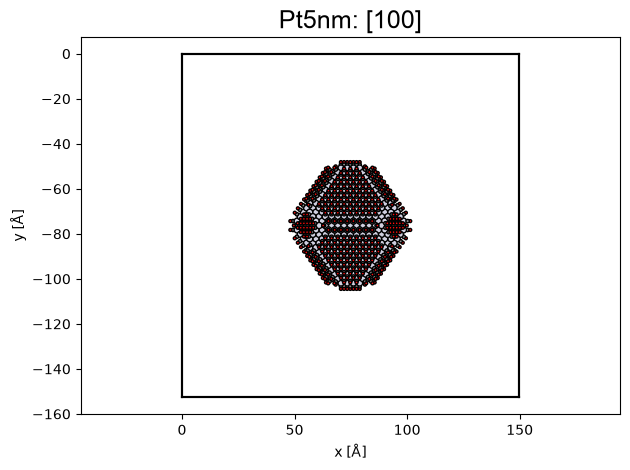

In [23]:
fig, ax = plt.subplots()
abtem.show_atoms(flip, ax=ax, scale=1)
ax.set_title(f"Pt5nm: [100]",fontsize=title_size, **font)
plt.tight_layout()

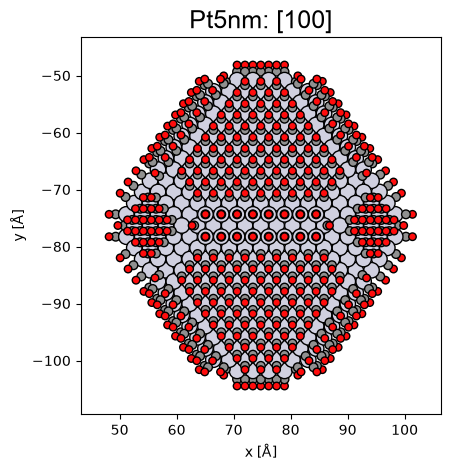

In [24]:
fig, ax = plt.subplots()

abtem.show_atoms(flip, ax=ax, scale=1)

pos = flip.positions

pad = 5.0

xmin = pos[:, 0].min() - pad
xmax = pos[:, 0].max() + pad
ymin = pos[:, 1].min() - pad
ymax = pos[:, 1].max() + pad

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal", adjustable="box")

ax.set_title(f"Pt5nm: [100]", fontsize=title_size, **font)
plt.tight_layout()

## Image settings

In [10]:
# Abberation from Visions TEM "Prime" by Idan Biran.
energy = 300e3 # Abberations are based of 300keV
C10 = 55         # Defocus            # 55 Å
C12 = 39.53      # A1, astigmatisme   # 3.953 nm
C23 = 204.7      # A2, trefoil        # 20.47 nm
C21 = 147.7      # B2, coma           # 14.77 nm
C30 = -14.72e4   # C3, Cs (spherical) # -14.72 µm
C34 = 1272       # A3, quadrafoil     # 127.2 nm
C32 = 695.6      # S3, astigmatisme2  # 69.56 nm
C45 = 5.28e4     # A4, pentafoil      # 5.28 µm
C43 = 3.033e4    # D4, trefoil2       # 3.022 µm
C41 = 9.802e4    # B4, coma2          # 9.892 µm
C50 = 7.606e7    # C5, C5 (spherical) # 7.606 mm
C56 = 202e4      # A4, hexafoil       # 202 µm

In [11]:
# Angle correction (phi) for abberations for the new TEM.
phi12 = 47.5*np.pi/180     # A1, astigmatisme   # 47.5°
phi23 = 81.5*np.pi/180     # A2, trefoil        # 81.5°
phi21 = 13.0*np.pi/180     # B2, coma           # 13.0°
# phi30 {C3, Cs (spherical)} has no phi dependency.
phi34 = -28.4*np.pi/180    # A3, quadrafoil     # -28.4°
phi32 = 41.7*np.pi/180     # S3, astigmatisme2  # 41.7°
phi45 = -109.7*np.pi/180   # A4, pentafoil      # -109.7°
phi43 = 131.8*np.pi/180    # D4, trefoil2       # 131.8°
phi41 = -63.0*np.pi/180    # B4, coma2          # -63.0°
# phi50 { C5, C5 (spherical)} has no phi dependency.
phi56 = -0.7*np.pi/180     # A4, hexafoil       # -0.7°

## Imaging

In [ ]:
# Load the data from the zarr file.
atom_ewave = abtem.from_zarr(data / "exit_waves/atom.zarr")

In [ ]:
# Focal settings from Visions TEM "Prime" by Idan Biran.
Cc = 1.6e-3 * 1e10 # Chromatic aberration in Å.
energy_spread = 0.105 # Use the best focal spread in eV
focal_spread = np.abs(Cc) * energy_spread / energy  # Focal spread for Titan.
focal_spread = focal_spread*np.sqrt(2) # Correction for temporal evelope in abTEM.

# Inserting abberation for PRIME.
# Spherical aberration_coefficients based of defocus = C10 = 0
# The C10 is defined without a vacuum, thus "C10 - buffer"
aberration_coefficients = {"C10": C10 - buffer, "C30": C30, "C50": C50}

# Creating the contrast transfer function 
ctf = abtem.CTF(aberration_coefficients=aberration_coefficients, energy=energy, focal_spread=focal_spread)


In [ ]:
prime = Pt.copy()
prime.rotate(180, (1, 0, 0), center=(0, 0, 0), rotate_cell=True)

In [ ]:
im = atom_ewave.apply_ctf(ctf).intensity()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

abtem.show_atoms(prime, ax = axes[0,0], scale = 1)
abtem.show_atoms(flip, ax = axes[0,0], scale = 1)
im.show(ax = axes[0,2], common_color_scale=True, cbar=True, cmap = "Greys_r")

axes[0,0].set_title(f"Pt5nm [110]",fontsize=title_size, **font)
axes[0,1].set_title(f"+Full coverage [110]",fontsize=title_size, **font)
axes[0,2].set_title(f"TEM Image: 55Å",fontsize=title_size, **font)

fig.tight_layout();
plt.savefig("step_for_step_im.svg", bbox_inches='tight')
plt.show()

# Quscope

## Load ASE model

In [3]:
# Load the model
atom = read(data/ f"models/Pt5nm_cov.traj")

In [4]:
atoms = read(data/ f"models/Pt5nm_cov.traj")

positions = atoms.get_positions()
symbols = atoms.get_chemical_symbols()

print(atoms)
print(atoms.cell)
print(atoms.pbc)

Atoms(symbols='C1016O1016Pt4045', pbc=False, cell=[149.5306167643286, 152.61921259771518, 149.5306167643286])
Cell([149.5306167643286, 152.61921259771518, 149.5306167643286])
[False False False]


In [5]:
slice_thickness = 1.0  # Å

z = atom.positions[:, 2]

zmin = z.min()
zmax = z.max()

n_slices = int(np.ceil((zmax - zmin) / slice_thickness))

print(f"Pt thickness: {zmax-zmin:.2f} Å")
print(f"Number of slices: {n_slices}")

Pt thickness: 53.22 Å
Number of slices: 54


In [6]:
print(atom)
print(atom.cell)
print(atom.get_positions().min(axis=0))
print(atom.get_positions().max(axis=0))

Atoms(symbols='C1016O1016Pt4045', pbc=False, cell=[149.5306167643286, 152.61921259771518, 149.5306167643286])
Cell([149.5306167643286, 152.61921259771518, 149.5306167643286])
[48.1562063 48.1562063 48.1562063]
[101.37441047 104.4630063  101.37441047]


In [7]:
extent = atom.get_positions().max(axis=0) - atom.get_positions().min(axis=0)

print(f"x extent = {extent[0]:.2f} Å")
print(f"y extent = {extent[1]:.2f} Å")
print(f"z extent = {extent[2]:.2f} Å")

x extent = 53.22 Å
y extent = 56.31 Å
z extent = 53.22 Å


In [8]:
print("cell:")
print(atom.cell[:])

cell:
[[149.53061676   0.           0.        ]
 [  0.         152.6192126    0.        ]
 [  0.           0.         149.53061676]]


In [10]:
from quscope.ctem import KirklandPotential

kirkland = KirklandPotential()

# Define the Kirkland parameterization of the electrostatic potential for an isolated Pt.
# Data from abTEM parameter https://raw.githubusercontent.com/abTEM/abTEM/main/abtem/parametrizations/data/kirkland.json
# Source: E. J. Kirkland, Advanced Computing in Electron Microscopy, 2nd ed., Springer, 2010.
kirkland.params_dict["Pt"] = [
    [0.98469794, 2.73987079, 3.61696715],       # a
    [0.160910839, 0.718971667, 12.9281016],     # b
    [0.302885602, 0.278370726, 0.0152124129],   # c
    [0.170134854, 1.49862703, 0.0283510822],    # d
]

# Replace the method on THIS instance
original_get_element_symbol = kirkland.get_element_symbol

def get_element_symbol(Z):
    if Z == 78:
        return "Pt"
    return original_get_element_symbol(Z)

kirkland.get_element_symbol = get_element_symbol
print(kirkland.get_element_symbol(78))
print(kirkland.get_parameters(78))

Pt
{'a': array([0.98469794, 2.73987079, 3.61696715]), 'b': array([ 0.16091084,  0.71897167, 12.9281016 ]), 'c': array([0.3028856 , 0.27837073, 0.01521241]), 'd': array([0.17013485, 1.49862703, 0.02835108])}


In [11]:
print("Pt in dictionary:", "Pt" in kirkland.params_dict)
print("Z=78:", kirkland.get_element_symbol(78))
print("Pt parameters:", kirkland.get_parameters(78))

Pt in dictionary: True
Z=78: Pt
Pt parameters: {'a': array([0.98469794, 2.73987079, 3.61696715]), 'b': array([ 0.16091084,  0.71897167, 12.9281016 ]), 'c': array([0.3028856 , 0.27837073, 0.01521241]), 'd': array([0.17013485, 1.49862703, 0.02835108])}


## testing new addition of Pt

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid
N = 256
pixel_size = 0.25

xs = np.linspace(0, pixel_size * N, N, endpoint=False)

X, Y = np.meshgrid(xs, xs, indexing="ij")

In [25]:
# Calculate a Pt potential
atom_x = 32.0
atom_y = 32.0

V_test = kirkland.calculate_2d(X, Y, atom_x=atom_x, atom_y=atom_y, Z=78)

In [26]:
# Find maximum
idx = np.unravel_index(
    np.argmax(V_test),
    V_test.shape,
)

print("Grid:")
print("  X range:", X.min(), X.max())
print("  Y range:", Y.min(), Y.max())

print("\nAtom:")
print("  atom_x =", atom_x)
print("  atom_y =", atom_y)

print("\nPotential:")
print("  shape =", V_test.shape)
print("  max   =", V_test.max())
print("  min   =", V_test.min())

print("\nMaximum:")
print("  index    =", idx)
print("  position =", X[idx], Y[idx])

print("\nValues:")
print("  corner (0,0)     =", V_test[0, 0])
print("  center (128,128) =", V_test[128, 128])

Grid:
  X range: 0.0 63.75
  Y range: 0.0 63.75

Atom:
  atom_x = 32.0
  atom_y = 32.0

Potential:
  shape = (256, 256)
  max   = 69058.07319807606
  min   = 1.9116884969825046e-48

Maximum:
  index    = (np.int64(128), np.int64(128))
  position = 32.0 32.0

Values:
  corner (0,0)     = 1.9116884969825046e-48
  center (128,128) = 69058.07319807606


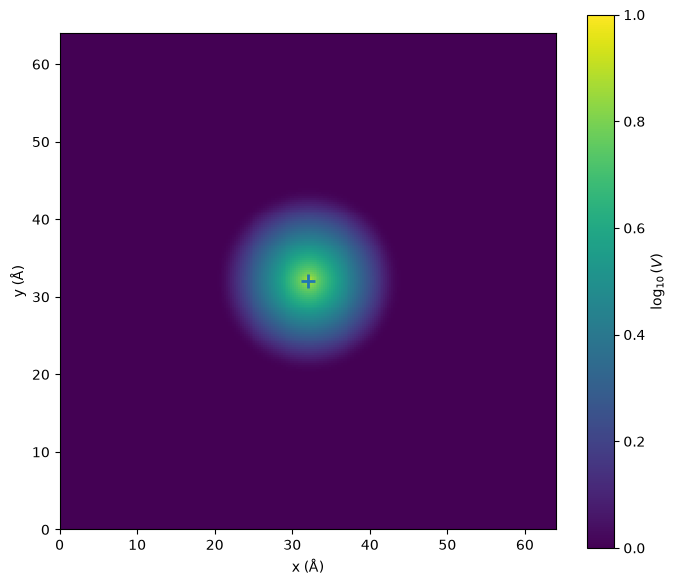

In [ ]:
# Plot
# r2 = (x_grid - atom_x) ** 2 + (y_grid - atom_y) ** 2
plt.figure(figsize=(7, 6))

plt.imshow(
    np.log10(V_test + 1e-10),
    extent=[0, 64, 0, 64],
    origin="lower",
    interpolation="nearest",
)

plt.scatter(
    [atom_x],
    [atom_y],
    marker="+",
    s=100,
    linewidths=2,
)

plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.colorbar(label=r"$\log_{10}(V)$")

plt.tight_layout()
plt.show()

## Attempt 1

In [46]:
"""
Convert an ASE Pt .traj structure into QuScope multislice potentials.

The output `potentials` has shape:
    (n_slices, grid_size, grid_size)

and can be passed to:
    QuantumMultisliceCircuit(params).simulate(list(potentials))
"""

from pathlib import Path

import numpy as np
from ase.io import read
from quscope.ctem import KirklandPotential


# ============================================================
# USER SETTINGS
# ============================================================

DATA_DIR = Path("data")
MODEL_FILE = DATA_DIR / "models" / "Pt5nm_cov.traj"

OUTPUT_DIR = DATA_DIR / "models"
OUTPUT_FILE = OUTPUT_DIR / "Pt5nm_cov_pot.npz"

GRID_SIZE = 256
PIXEL_SIZE = 0.25       # Angstrom / pixel
SLICE_THICKNESS = 1.0   # Angstrom


def center_positions(atom):
    """Center the atomic coordinates around (0, 0, 0)."""
    positions = atom.get_positions().copy()

    center = (
        positions.min(axis=0)
        + positions.max(axis=0)
    ) / 2.0

    return positions - center


def make_grid(grid_size, pixel_size):
    """Create the centered x/y grid used by QuScope."""
    x = (np.arange(grid_size) - grid_size / 2) * pixel_size
    y = (np.arange(grid_size) - grid_size / 2) * pixel_size

    return np.meshgrid(x, y, indexing="ij")


def build_potentials(
    atom,
    positions,
    grid_size=GRID_SIZE,
    pixel_size=PIXEL_SIZE,
    slice_thickness=SLICE_THICKNESS,
):
    """
    Build the QuScope multislice potential.

    Returns
    -------
    potentials : np.ndarray
        Shape (n_slices, grid_size, grid_size).
        Each slice is in the V*Angstrom convention expected by
        the quantum multislice circuit.
    """

    field_of_view = grid_size * pixel_size
    extent = positions.max(axis=0) - positions.min(axis=0)

    print("=" * 70)
    print("QU SCOPE GRID")
    print("=" * 70)
    print(f"Grid size      : {grid_size} x {grid_size}")
    print(f"Pixel size     : {pixel_size:.3f} Angstrom")
    print(f"Field of view  : {field_of_view:.3f} Angstrom")
    print(f"Pt extent x/y  : {extent[0]:.3f}, {extent[1]:.3f} Angstrom")

    if extent[0] > field_of_view or extent[1] > field_of_view:
        raise ValueError(
            f"Pt particle does not fit in the transverse field of view. "
            f"Particle extent = {extent[:2]}, "
            f"field of view = {field_of_view:.3f} Angstrom."
        )

    # Confirm this is a pure Pt model.
    unique_Z = np.unique(atom.get_atomic_numbers())
    if not np.all(unique_Z == 78):
        raise ValueError(
            f"This script expects a pure Pt model (Z=78), "
            f"but found atomic numbers: {unique_Z}"
        )

    # Use the Pt parameters already installed in your QuScope version.
    kirkland = KirklandPotential()

    print()
    print("Kirkland check:")
    print(f"Z=78 -> {kirkland.get_element_symbol(78)}")
    print(kirkland.get_parameters(78))

    X, Y = make_grid(grid_size, pixel_size)

    # Only the actual specimen thickness is sliced.
    # The large ASE vacuum is not included as physical slices.
    z_min = positions[:, 2].min()
    z_max = positions[:, 2].max()

    specimen_thickness = z_max - z_min
    n_slices = int(np.ceil(specimen_thickness / slice_thickness))

    print()
    print("MULTISLICE")
    print("=" * 70)
    print(f"Specimen thickness : {specimen_thickness:.3f} Angstrom")
    print(f"Slice thickness    : {slice_thickness:.3f} Angstrom")
    print(f"Number of slices   : {n_slices}")

    # Assign every atom to one z-slice.
    slice_indices = np.floor(
        (positions[:, 2] - z_min) / slice_thickness
    ).astype(int)

    slice_indices = np.clip(
        slice_indices,
        0,
        n_slices - 1,
    )

    potentials = np.zeros(
        (n_slices, grid_size, grid_size),
        dtype=np.float64,
    )

    # --------------------------------------------------------
    # Calculate each projected slice potential.
    # --------------------------------------------------------

    for i in range(n_slices):

        indices = np.where(slice_indices == i)[0]

        V_slice = np.zeros(
            (grid_size, grid_size),
            dtype=np.float64,
        )

        for index in indices:

            V_atom = kirkland.calculate_2d(
                X,
                Y,
                atom_x=positions[index, 0],
                atom_y=positions[index, 1],
                Z=78,
            )

            V_slice += V_atom

        # QuantumMultisliceCircuit uses:
        #
        #     phase = sigma * V
        #
        # with V in V*Angstrom.
        #
        # The slice potential is therefore integrated over dz.
        V_slice *= slice_thickness

        potentials[i] = V_slice

        print(
            f"Slice {i + 1:3d}/{n_slices}: "
            f"{len(indices):3d} atoms | "
            f"min={V_slice.min():.4e}, "
            f"max={V_slice.max():.4e}"
        )

    return potentials


def main():

    print("=" * 70)
    print("ASE -> QU SCOPE POTENTIAL")
    print("=" * 70)
    print(f"Input: {MODEL_FILE}")

    atom = read(MODEL_FILE)

    print(atom)
    print(f"Number of atoms: {len(atom)}")
    print(f"ASE cell:\n{atom.cell}")

    original_extent = (
        atom.get_positions().max(axis=0)
        - atom.get_positions().min(axis=0)
    )

    print(
        "Original atomic extent: "
        f"{original_extent[0]:.3f}, "
        f"{original_extent[1]:.3f}, "
        f"{original_extent[2]:.3f} Angstrom"
    )

    positions = center_positions(atom)

    potentials = build_potentials(
        atom,
        positions,
        grid_size=GRID_SIZE,
        pixel_size=PIXEL_SIZE,
        slice_thickness=SLICE_THICKNESS,
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        OUTPUT_FILE,
        potentials=potentials,
        positions=positions,
        grid_size=GRID_SIZE,
        pixel_size=PIXEL_SIZE,
        slice_thickness=SLICE_THICKNESS,
    )

    print()
    print("=" * 70)
    print("DONE")
    print("=" * 70)
    print(f"Potential file : {OUTPUT_FILE}")
    print(f"Potential shape: {potentials.shape}")
    print()
    print("Use in QuScope with:")
    print("    quscope_potentials = list(potentials)")
    print("    result = circuit.simulate(quscope_potentials)")
    print("=" * 70)


if __name__ == "__main__":
    main()


ASE -> QU SCOPE POTENTIAL
Input: data/models/Pt5nm_cov.traj


FileNotFoundError: [Errno 2] No such file or directory: 'data/models/Pt5nm_cov.traj'

## Create QuScope Model

In [5]:
import numpy as np
from ase.io import read
from collections import Counter
from quscope.ctem import KirklandPotential

# ============================================================
# Load Pt model
# ============================================================

atom = read(data / "models/Pt5nm_cov.traj")

positions = atom.get_positions().copy()


# ============================================================
# QuScope grid
# ============================================================

N = 256
pixel_size = 0.25  # Å/pixel

xs = np.linspace(
    0,
    pixel_size * N,
    N,
    endpoint=False,
)

X, Y = np.meshgrid(
    xs,
    xs,
    indexing="ij",
)

field_of_view = N * pixel_size

print(f"Field of view: {field_of_view:.2f} Å")


# ============================================================
# Center particle in QuScope transverse field of view
# ============================================================

positions = atom.get_positions().copy()

# Original particle bounds
mins = positions.min(axis=0)
maxs = positions.max(axis=0)

extent = maxs - mins

print("\nOriginal particle extent:")
print(f"x = {extent[0]:.2f} Å")
print(f"y = {extent[1]:.2f} Å")
print(f"z = {extent[2]:.2f} Å")


# ------------------------------------------------------------
# Shift particle so its minimum x/y/z coordinates are zero
# ------------------------------------------------------------

positions -= mins


# ------------------------------------------------------------
# Center x/y in the QuScope field
# ------------------------------------------------------------

positions[:, 0] += (
    field_of_view - extent[0]
) / 2

positions[:, 1] += (
    field_of_view - extent[1]
) / 2


# z remains:
# 0 → specimen thickness


# ============================================================
# Check final coordinates
# ============================================================

print("\nFinal particle coordinates:")

print(
    f"x = {positions[:, 0].min():.2f}"
    f" → {positions[:, 0].max():.2f} Å"
)

print(
    f"y = {positions[:, 1].min():.2f}"
    f" → {positions[:, 1].max():.2f} Å"
)

print(
    f"z = {positions[:, 2].min():.2f}"
    f" → {positions[:, 2].max():.2f} Å"
)

print("\nFinal extent:")
final_extent = positions.max(axis=0) - positions.min(axis=0)

print(f"x = {final_extent[0]:.2f} Å")
print(f"y = {final_extent[1]:.2f} Å")
print(f"z = {final_extent[2]:.2f} Å")


# ============================================================
# Kirkland Pt potential
# ============================================================

kirkland = KirklandPotential()

kirkland.params_dict["Pt"] = [
    [0.98469794, 2.73987079, 3.61696715],
    [0.160910839, 0.718971667, 12.9281016],
    [0.302885602, 0.278370726, 0.0152124129],
    [0.170134854, 1.49862703, 0.0283510822],
]

original_get_element_symbol = kirkland.get_element_symbol

def get_element_symbol(Z):
    if Z == 78:
        return "Pt"
    return original_get_element_symbol(Z)

kirkland.get_element_symbol = get_element_symbol


# ============================================================
# Slice along z
# ============================================================

slice_thickness = 1.0  # Å

z_min = positions[:, 2].min()
z_max = positions[:, 2].max()

n_slices = int(
    np.ceil((z_max - z_min) / slice_thickness)
)

print(f"\nSpecimen thickness: {z_max - z_min:.2f} Å")
print(f"Slice thickness:    {slice_thickness:.2f} Å")
print(f"Number of slices:   {n_slices}")


# ============================================================
# Assign atoms to slices
# ============================================================

slice_indices = np.floor(
    (positions[:, 2] - z_min) / slice_thickness
).astype(int)

slice_indices = np.clip(
    slice_indices,
    0,
    n_slices - 1,
)


# ============================================================
# Build potentials
# ============================================================

potentials = []
atomic_numbers = atom.get_atomic_numbers()

from collections import Counter

for i in range(n_slices):

    indices = np.where(
        slice_indices == i
    )[0]

    V_slice = np.zeros(
        (N, N),
        dtype=float,
    )

    for index in indices:

        x_atom = positions[index, 0]
        y_atom = positions[index, 1]
        Z = atomic_numbers[index]

        V_atom = kirkland.calculate_2d(
            X,
            Y,
            atom_x=x_atom,
            atom_y=y_atom,
            Z=Z,
        )

        V_slice += V_atom

    potentials.append(V_slice)

    # Composition of THIS slice
    slice_composition = Counter(
        symbols[index] for index in indices
    )

    print(
        f"Slice {i+1:3d}/{n_slices}: "
        f"{len(indices):3d} atoms | "
        f"{dict(slice_composition)} | "
        f"max = {V_slice.max():.4e}"
    )

potentials = np.asarray(potentials)

print("\nFinal potential:")
print("shape =", potentials.shape)

Field of view: 64.00 Å

Original particle extent:
x = 53.22 Å
y = 56.31 Å
z = 53.22 Å

Final particle coordinates:
x = 5.39 → 58.61 Å
y = 3.85 → 60.15 Å
z = 0.00 → 53.22 Å

Final extent:
x = 53.22 Å
y = 56.31 Å
z = 53.22 Å

Specimen thickness: 53.22 Å
Slice thickness:    1.00 Å
Number of slices:   54
Slice   1/54:  16 atoms | {'O': 16} | max = 6.7831e+02
Slice   2/54:  36 atoms | {'C': 16, 'O': 20} | max = 6.8097e+02
Slice   3/54:  20 atoms | {'C': 20} | max = 1.9026e+03
Slice   4/54:  40 atoms | {'Pt': 16, 'O': 24} | max = 4.7513e+03
Slice   5/54:  83 atoms | {'Pt': 29, 'C': 24, 'O': 30} | max = 6.9059e+04
Slice   6/54:  74 atoms | {'Pt': 44, 'C': 30} | max = 6.0012e+03
Slice   7/54:  44 atoms | {'C': 12, 'O': 32} | max = 8.4307e+02
Slice   8/54: 119 atoms | {'Pt': 61, 'O': 34, 'C': 24} | max = 6.9059e+04
Slice   9/54: 146 atoms | {'Pt': 80, 'C': 34, 'O': 32} | max = 6.0009e+03
Slice  10/54: 129 atoms | {'Pt': 93, 'C': 28, 'O': 8} | max = 6.9059e+04
Slice  11/54:  30 atoms | {'C': 12,

In [9]:
# ============================================================
# Save QuScope potential model
# ============================================================

output_file = data / "models" / "Pt5nm_cov_quscope.npz"

np.savez_compressed(
    output_file,
    potentials=potentials,
    positions=positions,
    atomic_numbers=atomic_numbers,
    grid_size=N,
    pixel_size=pixel_size,
    slice_thickness=slice_thickness,
    field_of_view=field_of_view,
)

print("\nSaved QuScope potential:")
print(output_file)


Saved QuScope potential:
/zhome/f1/0/167759/10387/data/models/Pt5nm_cov_quscope.npz


## Test Model

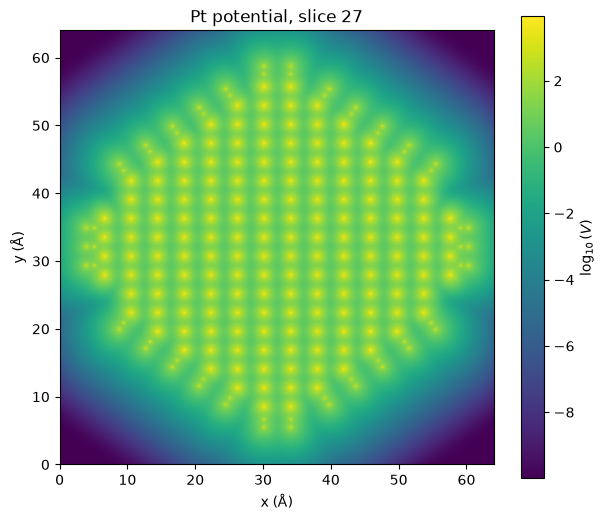

In [49]:
import matplotlib.pyplot as plt

# Find a non-empty slice near the middle
i = len(potentials) // 2

plt.figure(figsize=(7, 6))

plt.imshow(
    np.log10(potentials[i] + 1e-10),
    extent=[0, 64, 0, 64],
    origin="lower",
)

plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.colorbar(label=r"$\log_{10}(V)$")

plt.title(f"Pt potential, slice {i}")

plt.show()

In [50]:
print("Atom x range:",
      positions[:, 0].min(),
      positions[:, 0].max())

print("Atom y range:",
      positions[:, 1].min(),
      positions[:, 1].max())

print("Vacuum x:")
print(
    positions[:, 0].min(),
    64 - positions[:, 0].max()
)

print("Vacuum y:")
print(
    positions[:, 1].min(),
    64 - positions[:, 1].max()
)

Atom x range: 5.39089791669322 58.60910208330678
Atom y range: 3.8465999999999525 60.15340000000005
Vacuum x:
5.39089791669322 5.39089791669322
Vacuum y:
3.8465999999999525 3.8465999999999525


In [51]:
V = potentials[27]

print("Maximum potential:", V.max())

print("Boundary maximum:")
print(
    max(
        V[0, :].max(),
        V[-1, :].max(),
        V[:, 0].max(),
        V[:, -1].max(),
    )
)

print("Boundary / maximum:")
print(
    max(
        V[0, :].max(),
        V[-1, :].max(),
        V[:, 0].max(),
        V[:, -1].max(),
    ) / V.max()
)

Maximum potential: 8705.101737682397
Boundary maximum:
0.04670686241362756
Boundary / maximum:
5.3654585346710215e-06


In [52]:
tot_atoms = 0
for i in range(len(potentials)):
    tot_atoms += (slice_indices == i).sum()
    print(
        f"{i:2d}: "
        f"atoms = {(slice_indices == i).sum():3d}, "
        f"max = {potentials[i].max():.3e}"
    )
print(tot_atoms)

 0: atoms =  16, max = 6.783e+02
 1: atoms =  36, max = 6.810e+02
 2: atoms =  20, max = 1.903e+03
 3: atoms =  40, max = 4.751e+03
 4: atoms =  83, max = 6.906e+04
 5: atoms =  74, max = 6.001e+03
 6: atoms =  44, max = 8.431e+02
 7: atoms = 119, max = 6.906e+04
 8: atoms = 146, max = 6.001e+03
 9: atoms = 129, max = 6.906e+04
10: atoms =  30, max = 6.741e+02
11: atoms = 150, max = 8.071e+03
12: atoms = 149, max = 6.906e+04
13: atoms =  36, max = 7.023e+02
14: atoms = 168, max = 8.705e+03
15: atoms = 197, max = 6.906e+04
16: atoms = 198, max = 8.705e+03
17: atoms =   8, max = 5.298e+02
18: atoms = 197, max = 6.906e+04
19: atoms = 200, max = 8.705e+03
20: atoms =  12, max = 1.731e+03
21: atoms = 201, max = 6.906e+04
22: atoms = 224, max = 8.705e+03
23: atoms = 225, max = 6.906e+04
24: atoms =   0, max = 0.000e+00
25: atoms = 224, max = 8.705e+03
26: atoms = 225, max = 6.906e+04
27: atoms = 224, max = 8.705e+03
28: atoms =   0, max = 0.000e+00
29: atoms = 225, max = 6.906e+04
30: atoms 

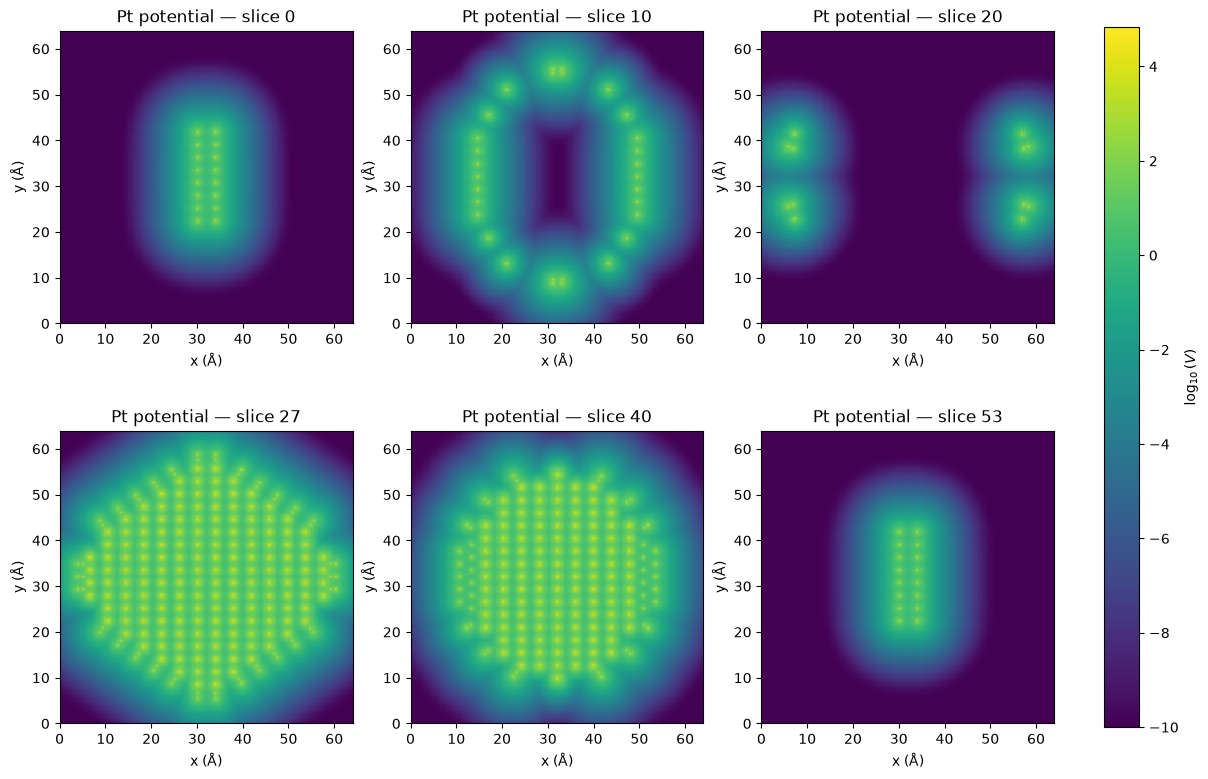

In [53]:
import matplotlib.pyplot as plt
import numpy as np

slice_ids = [0, 10, 20, 27, 40, 53]

V_log = np.log10(potentials[slice_ids] + 1e-10)

vmin = V_log.min()
vmax = V_log.max()

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 8),
    constrained_layout=True,
)

for ax, i, V in zip(axes.flat, slice_ids, V_log):

    im = ax.imshow(
        V,
        extent=[0, 64, 0, 64],
        origin="lower",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(f"Pt potential — slice {i}")
    ax.set_xlabel("x (Å)")
    ax.set_ylabel("y (Å)")

fig.colorbar(
    im,
    ax=axes,
    label=r"$\log_{10}(V)$",
    shrink=0.9,
)

plt.show()

### Testing

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rcParams.update({'font.family': 'serif', 'font.size': 10,
                     'axes.titlesize': 11, 'figure.dpi': 120})

from quscope.quantum_ctem.quantum_multislice_circuit import (
    QuantumMultisliceParameters,
    FresnelPropagatorCircuit,
    QuantumMultisliceCircuit,
    QuantumClassicalMultisliceValidator,
)
from quscope.quantum_ctem.quantum_ctem_circuit import (
    relativistic_wavelength,
    interaction_constant,
)

print('Imports OK')
lam = relativistic_wavelength(200e3)
print(f'λ at 200 kV = {lam*1000:.4f} pm')

Imports OK
λ at 200 kV = 25.0793 pm


In [50]:
N = 8
a_mos2    = 3.18          # Å, MoS2 lattice constant
pixel_size = a_mos2 * 4 / N  # Å/px

params = QuantumMultisliceParameters(
    acceleration_voltage = 200e3,   # V
    grid_size            = N,
    pixel_size           = pixel_size,
    defocus              = -500.0,  # Å (slight underfocus)
    cs                   = 1.3,     # mm
    slice_thickness      = 3.18,    # Å — one MoS2 monolayer
)

lam_v  = relativistic_wavelength(params.acceleration_voltage)
sigma  = interaction_constant(params.acceleration_voltage, lam_v)

print(f'Grid          : {N}×{N}')
print(f'pixel_size    : {pixel_size:.3f} Å/px')
print(f'slice_thickness: {params.slice_thickness} Å')
print(f'λ             : {lam_v*1000:.4f} pm')
print(f'σ             : {sigma:.4f} rad/(V·Å)')
print(f'n_qubits      : {2*int(np.log2(N))} ({int(np.log2(N))} per dim)')


Grid          : 8×8
pixel_size    : 1.590 Å/px
slice_thickness: 3.18 Å
λ             : 25.0793 pm
σ             : 0.0007 rad/(V·Å)
n_qubits      : 6 (3 per dim)


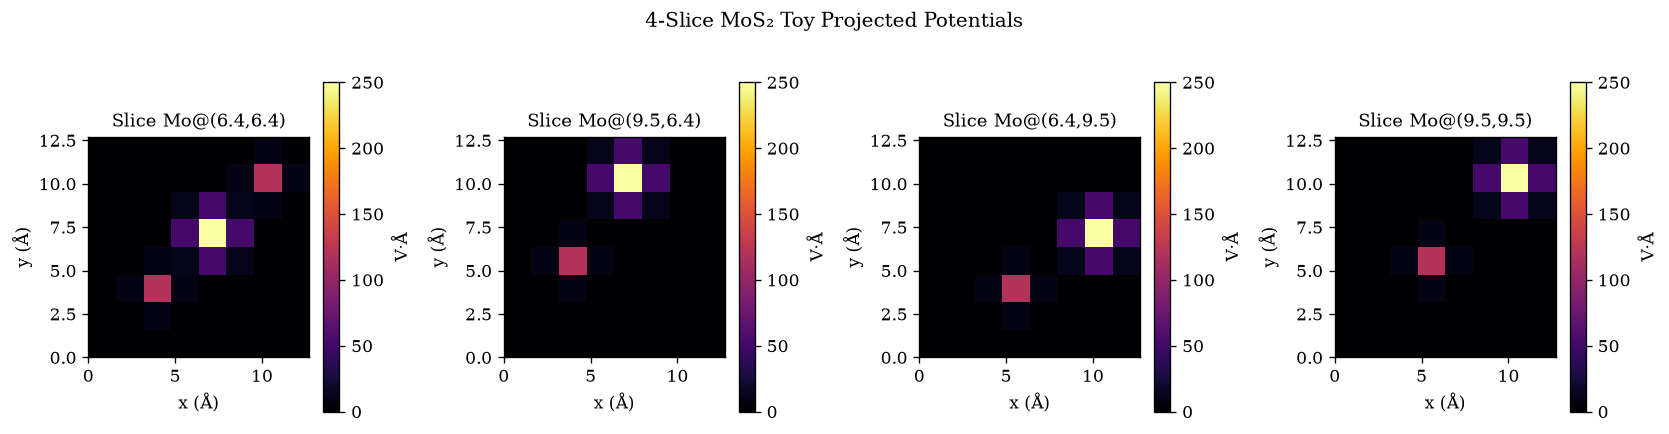

Potential range: [0.0, 250.0] V·Å


In [51]:
xs = np.linspace(0, pixel_size * N, N, endpoint=False)
X, Y = np.meshgrid(xs, xs, indexing='ij')

def make_potential(cx, cy, amp_Mo=250.0, amp_S=120.0, sigma_Mo=0.9, sigma_S=0.7):
    """Gaussian toy potential for one MoS2 layer."""
    V  = amp_Mo * np.exp(-((X-cx)**2 + (Y-cy)**2) / (2*sigma_Mo**2))
    V += amp_S  * np.exp(-((X-cx/2)**2 + (Y-cy/2)**2) / (2*sigma_S**2))
    V += amp_S  * np.exp(-((X-cx*1.5)**2 + (Y-cy*1.5)**2) / (2*sigma_S**2))
    return V

L = pixel_size * N
offsets = [(L/2, L/2), (L/2 + a_mos2, L/2),
           (L/2, L/2 + a_mos2),   (L/2 + a_mos2, L/2 + a_mos2)]

potentials = [make_potential(cx, cy) for cx, cy in offsets]

# Visualise all slices
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, V, (cx, cy) in zip(axes, potentials, offsets):
    im = ax.imshow(V, cmap='inferno', origin='lower',
                   extent=[0, L, 0, L])
    plt.colorbar(im, ax=ax, label='V·Å')
    ax.set_title(f'Slice Mo@({cx:.1f},{cy:.1f})')
    ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)')
plt.suptitle('4-Slice MoS₂ Toy Projected Potentials', y=1.02)
plt.tight_layout()
plt.show()

print(f'Potential range: [{min(V.min() for V in potentials):.1f}, '
      f'{max(V.max() for V in potentials):.1f}] V·Å')

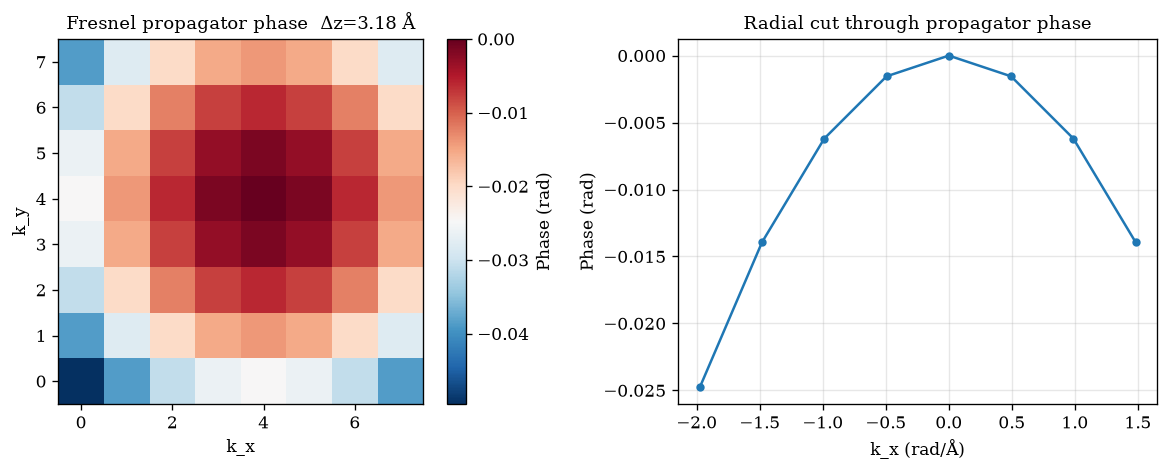

In [52]:
n_q = int(np.log2(N))
fpc = FresnelPropagatorCircuit(2*n_q, n_q, n_q)
phase_k = fpc.calculate_propagator_phase(lam_v, pixel_size, params.slice_thickness)

freq_x = np.fft.fftfreq(N, d=pixel_size)
kx = np.fft.fftshift(2 * np.pi * freq_x)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
im = ax.imshow(np.fft.fftshift(phase_k), cmap='RdBu_r', origin='lower')
plt.colorbar(im, ax=ax, label='Phase (rad)')
ax.set_title(f'Fresnel propagator phase  Δz={params.slice_thickness} Å')
ax.set_xlabel('k_x'); ax.set_ylabel('k_y')

ax = axes[1]
radial = np.fft.fftshift(phase_k)[N//2, :]
ax.plot(kx, radial, 'C0-o', ms=4)
ax.set_xlabel('k_x (rad/Å)'); ax.set_ylabel('Phase (rad)')
ax.set_title('Radial cut through propagator phase')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [53]:
qmc = QuantumMultisliceCircuit(params)
qc  = qmc.build_full_circuit(potentials, include_barriers=True)

print('=== Circuit Stats ===')
print(f'  n_qubits : {qc.num_qubits}')
print(f'  depth    : {qc.depth()}')
print(f'  n_slices : {len(potentials)}')
print()
print('Gate counts:')
for gate, count in sorted(qc.count_ops().items(), key=lambda x: -x[1]):
    print(f'  {gate:<25} {count}')

=== Circuit Stats ===
  n_qubits : 6
  depth    : 17
  n_slices : 4

Gate counts:
  diagonal                  8
  qft                       8
  qft_dg                    8
  h                         6
  barrier                   6


In [54]:
# Draw the circuit (text — compact overview)
try:
    print(qc.draw('text', fold=120))
except Exception:
    print('(circuit draw unavailable in this environment)')

     ┌───┐ |ψ_in⟩ »
q_0: ┤ H ├───░────»
     ├───┤   ░    »
q_1: ┤ H ├───░────»
     ├───┤   ░    »
q_2: ┤ H ├───░────»
     ├───┤   ░    »
q_3: ┤ H ├───░────»
     ├───┤   ░    »
q_4: ┤ H ├───░────»
     ├───┤   ░    »
q_5: ┤ H ├───░────»
     └───┘   ░    »
«     ┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Exit-wave stats:
  shape   : (8, 8)
  |ψ|_max : 0.1405
  ∑|ψ|²   : 1.0000   (1.0 = norm-conserved)


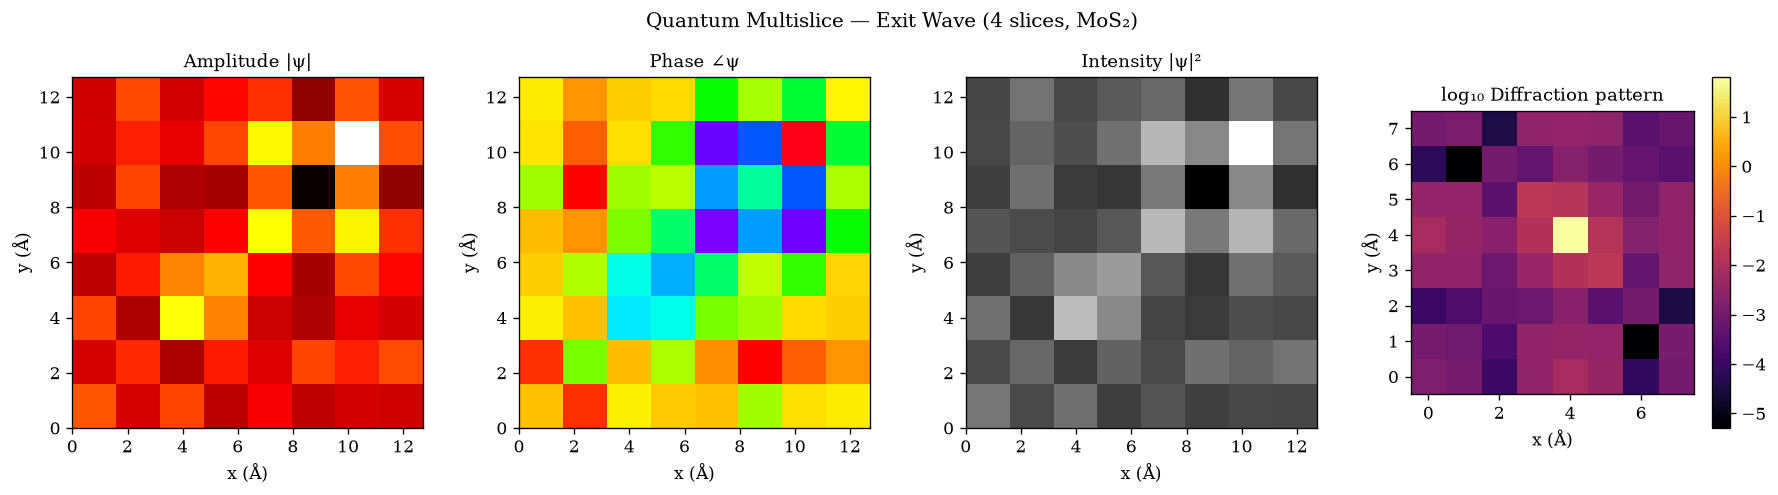

In [55]:
result = qmc.simulate(potentials)

wave  = result['wave_function']
amp   = result['amplitude']
phase = result['phase']
intens = result['intensity']

print('Exit-wave stats:')
print(f'  shape   : {wave.shape}')
print(f'  |ψ|_max : {amp.max():.4f}')
print(f'  ∑|ψ|²   : {intens.sum():.4f}   (1.0 = norm-conserved)')

# Diffraction pattern
dp = np.fft.fftshift(np.abs(np.fft.fft2(wave))**2)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
ex = [0, L, 0, L]
kw  = dict(origin='lower', extent=ex)

axes[0].imshow(amp,   cmap='hot',    **kw); axes[0].set_title('Amplitude |ψ|')
axes[1].imshow(phase, cmap='hsv',    **kw); axes[1].set_title('Phase ∠ψ')
axes[2].imshow(intens,cmap='gray',   **kw); axes[2].set_title('Intensity |ψ|²')
im = axes[3].imshow(np.log10(dp + 1e-10), cmap='inferno', origin='lower')
axes[3].set_title('log₁₀ Diffraction pattern')
plt.colorbar(im, ax=axes[3])

for ax in axes:
    ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)')
plt.suptitle('Quantum Multislice — Exit Wave (4 slices, MoS₂)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [56]:
validator = QuantumClassicalMultisliceValidator(params)
comp = validator.compare(potentials)

print('=== Quantum vs Classical ===')
print(f'  Fidelity : {comp["fidelity"]:.6f}   (1.0 = perfect)')
print(f'  RMSE     : {comp["rmse"]:.6f}')

=== Quantum vs Classical ===
  Fidelity : 1.000000   (1.0 = perfect)
  RMSE     : 0.000000


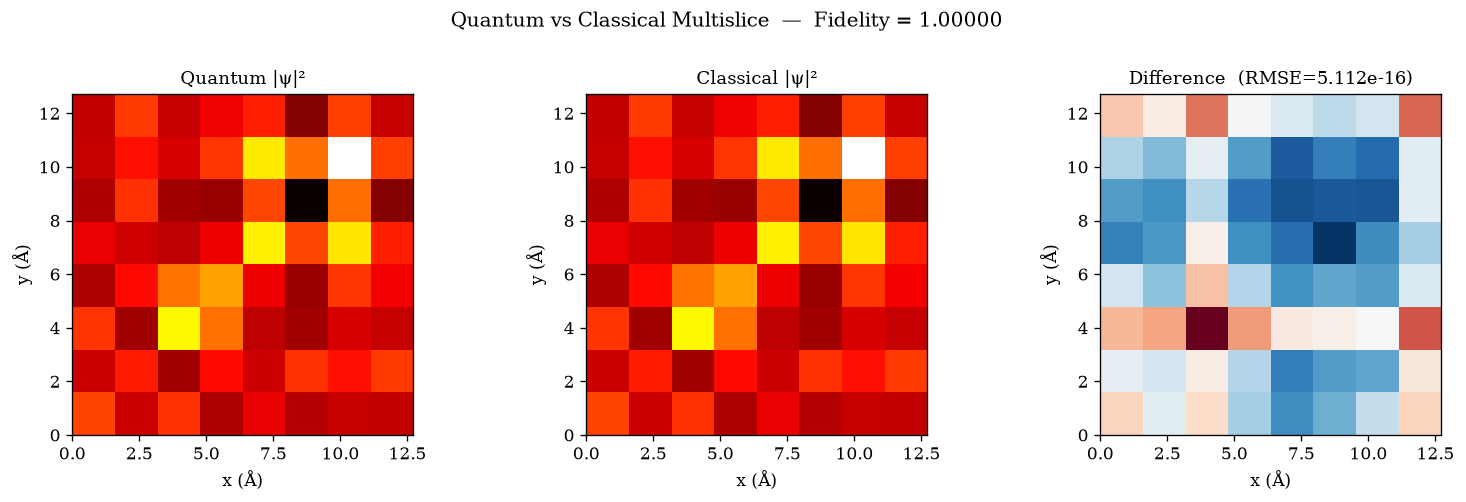

In [57]:
# Side-by-side intensity maps: quantum vs classical
c_wave  = validator.classical_multislice(potentials)
c_intens = np.abs(c_wave)**2
q_intens = intens

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
kw = dict(origin='lower', extent=ex, cmap='hot')

axes[0].imshow(q_intens, **kw); axes[0].set_title('Quantum |ψ|²')
axes[1].imshow(c_intens, **kw); axes[1].set_title('Classical |ψ|²')

diff = q_intens - c_intens
vabs = max(abs(diff.min()), abs(diff.max())) or 1e-6
axes[2].imshow(diff, cmap='RdBu_r', origin='lower', extent=ex,
               vmin=-vabs, vmax=vabs)
axes[2].set_title(f'Difference  (RMSE={comp["rmse"]:.3e})')

for ax in axes:
    ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)')

plt.suptitle(f'Quantum vs Classical Multislice  —  Fidelity = {comp["fidelity"]:.5f}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('quantum_multislice_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

  n_slices= 1  fidelity=1.000000  rmse=1.3828e-16
  n_slices= 2  fidelity=1.000000  rmse=2.5719e-16
  n_slices= 4  fidelity=1.000000  rmse=5.1205e-16


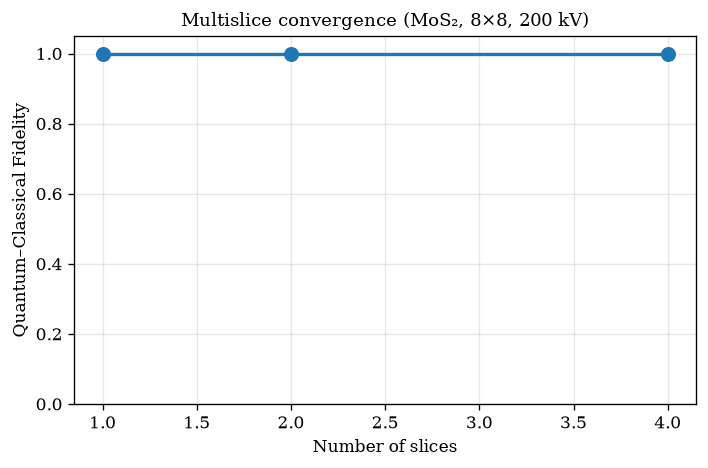

In [58]:
V_total = sum(potentials)

n_slice_vals = [1, 2, 4]
results_fid  = []

for ns in n_slice_vals:
    slices_ns = [V_total / ns for _ in range(ns)]
    p_ns = QuantumMultisliceParameters(
        acceleration_voltage = params.acceleration_voltage,
        grid_size            = N,
        pixel_size           = pixel_size,
        defocus              = params.defocus,
        cs                   = params.cs,
        slice_thickness      = params.slice_thickness,
    )
    val_ns = QuantumClassicalMultisliceValidator(p_ns)
    c_ns   = val_ns.compare(slices_ns)
    results_fid.append(c_ns['fidelity'])
    print(f'  n_slices={ns:2d}  fidelity={c_ns["fidelity"]:.6f}  rmse={c_ns["rmse"]:.4e}')

plt.figure(figsize=(6, 4))
plt.plot(n_slice_vals, results_fid, 'C0-o', ms=8, lw=2)
plt.xlabel('Number of slices')
plt.ylabel('Quantum–Classical Fidelity')
plt.title('Multislice convergence (MoS₂, 8×8, 200 kV)')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## QuScope Imaging

In [10]:
potential_file = data / "models" / "Pt5nm_cov_quscope.npz"

model = np.load(potential_file)

potentials = model["potentials"]
grid_size = int(model["grid_size"])
pixel_size = float(model["pixel_size"])
slice_thickness = float(model["slice_thickness"])
field_of_view = float(model["field_of_view"])

print("Potential shape:", potentials.shape)
print("Grid size:", grid_size)
print("Pixel size:", pixel_size)
print("Slice thickness:", slice_thickness)
print("FOV:", field_of_view)

Potential shape: (54, 256, 256)
Grid size: 256
Pixel size: 0.25
Slice thickness: 1.0
FOV: 64.0


### Computation time test:

In [17]:
grid_size = 256
pixel_size = 0.25
lc = 3.92
slice_thickness = lc / 8

In [18]:
mid = len(potentials) // 2

test_potentials = potentials[mid-1:mid+2]

print("Middle slices:", mid-1, mid, mid+1)
print("Shape:", test_potentials.shape)

Middle slices: 26 27 28
Shape: (3, 256, 256)


In [19]:
params = QuantumMultisliceParameters(
    acceleration_voltage=300e3,
    grid_size=256,
    pixel_size=0.25,
    defocus=-500,
    cs=1.3,
    slice_thickness=lc / 8,
)

circuit = QuantumMultisliceCircuit(params)

result = circuit.simulate(test_potentials)

In [20]:
print(result.keys())

dict_keys(['statevector', 'wave_function', 'amplitude', 'phase', 'intensity'])


In [21]:
for key, value in result.items():
    print(key, type(value))

statevector <class 'numpy.ndarray'>
wave_function <class 'numpy.ndarray'>
amplitude <class 'numpy.ndarray'>
phase <class 'numpy.ndarray'>
intensity <class 'numpy.ndarray'>


### Quantum Multislice

In [55]:
grid_size = 256
pixel_size = 0.25

lc = 3.92
slice_thickness = lc / 8

energy = 300e3 

In [ ]:
params = QuantumMultisliceParameters(
    acceleration_voltage=energy,
    grid_size=grid_size,
    pixel_size=pixel_size,
    defocus=-500,
    cs=1.3,
    slice_thickness=lc / 8,
)

circuit = QuantumMultisliceCircuit(params)

result = circuit.simulate(potentials)

In [ ]:
wave  = result['wave_function']
amp   = result['amplitude']
phase = result['phase']
intens = result['intensity']

print('Exit-wave stats:')
print(f'  shape   : {wave.shape}')
print(f'  |ψ|_max : {amp.max():.4f}')
print(f'  ∑|ψ|²   : {intens.sum():.4f}   (1.0 = norm-conserved)')

# Diffraction pattern
dp = np.fft.fftshift(np.abs(np.fft.fft2(wave))**2)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
ex = [0, L, 0, L]
kw  = dict(origin='lower', extent=ex)

axes[0].imshow(amp,   cmap='hot',    **kw); axes[0].set_title('Amplitude |ψ|')
axes[1].imshow(phase, cmap='hsv',    **kw); axes[1].set_title('Phase ∠ψ')
axes[2].imshow(intens,cmap='gray',   **kw); axes[2].set_title('Intensity |ψ|²')
im = axes[3].imshow(np.log10(dp + 1e-10), cmap='inferno', origin='lower')
axes[3].set_title('log₁₀ Diffraction pattern')
plt.colorbar(im, ax=axes[3])

for ax in axes:
    ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)')
plt.suptitle('Quantum Multislice — Exit Wave (4 slices, MoS₂)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()